# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh


rng = np.random.default_rng(0)

In [6]:
d = 40
k = 8
sigma = 0.1
n = 1500

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)


## Low-Rank vs Diffuse Coefficient Changes

In [8]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [9]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

S_lr = (sample(W0 + DeltaW_lr).T @ sample(W0 + DeltaW_lr)) / n
S_dense = (sample(W0 + DeltaW_dense).T @ sample(W0 + DeltaW_dense)) / n

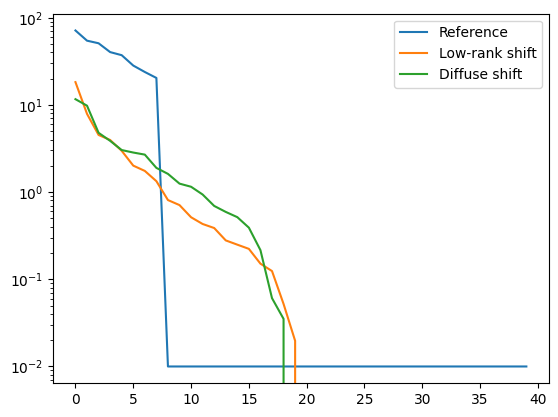

In [10]:
eig0 = eigvalsh(Sigma0)
eig_lr = eigvalsh(S_lr)
eig_dense = eigvalsh(S_dense)

plt.semilogy(eig0[::-1], label='Reference')
plt.semilogy(eig_lr[::-1], label='Low-rank shift')
plt.semilogy(eig_dense[::-1], label='Diffuse shift')
plt.legend()
plt.show()

In [22]:
threshold = 0.15
num_sig_lr = np.sum(np.abs(eig_lr[::-1] - eig0) > threshold)
num_sig_dense = np.sum(np.abs(eig_dense[::-1] - eig0) > threshold)


print("Significantly changed eigenvalues:")
print("low-rank:", num_sig_lr)
print("diffuse:", num_sig_dense)


Significantly changed eigenvalues:
low-rank: 33
diffuse: 36


In [ ]:
#1. In the low-rank case 33 eigenvalues change substantially. This is larger than the rank of the coefficient modification.
# Most of the change happens in directions not modified, which matches the low rank of the change. The other directions don't change much.

#2. In the diffuse case, 36 eigenvalues change as the modification is spread across almost all directions of the data space.
# Even though the total size of the change is the same, lots of directions results in more variance thus more eigenvalues are effective.

#3. This shows that the rank of a matrix is the limit for how many directions of variance can change. Low-rank changes
# affect a few directions (and their eigenvalues), while diffuse changes spreads across many directions.